# Exploratory Data Analysis — Purkinje Cell Spike Dataset

This notebook performs EDA on `aligned_df_1D1` and `aligned_df_1D2` produced by the dataset creation pipeline.

**DataFrame schema:**
- `lick_id` — lick event index
- `label` — behaviour label (0=Grooming, integers=lick types)
- `bout_tag` / `harvest_tag` — trial-level grouping metadata
- `velocity_max` — peak tongue velocity (m/s)
- `deceleration_min` — minimum velocity during retraction
- `decel_strength` — approximate deceleration rate (Δv/Δt)
- `electrode` — electrode index
- `spike_time` — spike timestamp relative to lick onset (s), in range [-0.1, 0]
- `spike_type` — `'SS'` (simple spike) or `'CS'` (complex spike)

## Setup — Imports & Aesthetic Theme

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ── Global aesthetic theme ───────────────────────────────────
BG        = '#F7F4EF'   # warm off-white canvas
PANEL     = '#FFFFFF'   # pure white panels
GRID      = '#E8E4DC'   # barely-there grid
TEXT      = '#1C1C1C'   # near-black text
MUTED     = '#7A7570'   # warm grey for axes/labels
ACCENT1   = '#3A6EA5'   # steel blue  → simple spikes
ACCENT2   = '#C0513A'   # terracotta  → complex spikes
ACCENT3   = '#E8A838'   # amber       → highlights / medians
ACCENT4   = '#5A8A6A'   # sage green
ACCENT5   = '#7B5EA7'   # muted violet

# Custom colormaps
CMAP_DUAL  = LinearSegmentedColormap.from_list('dual', [ACCENT2, '#F5F5F5', ACCENT1])

print('Theme loaded ✓')


Theme loaded ✓


## 1 — Load & Merge DataFrames

In [4]:
# Load from CSVs produced by the pipeline
df1 = pd.read_csv('aligned_spikes_1D1.csv')
df2 = pd.read_csv('aligned_spikes_1D2.csv')

# Tag source file
df1['source'] = '1D_1'
df2['source'] = '1D_2'

# Combined view
df_all = pd.concat([df1, df2], ignore_index=True)

# Label map  (adjust if your data uses different IDs)
LABEL_MAP = {
    0: 'Grooming',
    1: 'Lick-1',
    2: 'Lick-2',
    3: 'Lick-3',
    4: 'Lick-4',
    5: 'Lick-5',
    6: 'Lick-6',
    7: 'Spontaneous',
}
df_all['label_name'] = df_all['label'].map(LABEL_MAP).fillna(df_all['label'].astype(str))

print(f'1D_1 rows : {len(df1):>8,}')
print(f'1D_2 rows : {len(df2):>8,}')
print(f'Combined  : {len(df_all):>8,}')
print()
df_all.head()

1D_1 rows :   46,152
1D_2 rows :   11,715
Combined  :   57,867



,lick_id,label,bout_tag,harvest_tag,velocity_max,deceleration_min,decel_strength,electrode,spike_time,spike_type,source,label_name
0,0,7,1.0,1.0,297.269116,-385.653512,1415.567221,0,-0.097,SS,1D_1,Spontaneous
1,0,7,1.0,1.0,297.269116,-385.653512,1415.567221,0,-0.091,SS,1D_1,Spontaneous
2,0,7,1.0,1.0,297.269116,-385.653512,1415.567221,0,-0.086,SS,1D_1,Spontaneous
3,0,7,1.0,1.0,297.269116,-385.653512,1415.567221,0,-0.082,SS,1D_1,Spontaneous
4,0,7,1.0,1.0,297.269116,-385.653512,1415.567221,0,-0.075,SS,1D_1,Spontaneous


## 2 — Dataset Overview

In [5]:
# ── Summary statistics ────────────────────────────────────────────────────────
for name, df in [('1D_1', df1), ('1D_2', df2), ('Combined', df_all)]:
    print(f'═══ {name} ══════════════════════════')
    print(f'  Total spikes  : {len(df):,}')
    print(f'  Unique licks  : {df["lick_id"].nunique():,}')
    print(f'  Electrodes    : {df["electrode"].nunique()}')
    ss = (df['spike_type']=='SS').sum()
    cs = (df['spike_type']=='CS').sum()
    print(f'  SS spikes     : {ss:,}  ({100*ss/len(df):.1f}%)')
    print(f'  CS spikes     : {cs:,}  ({100*cs/len(df):.1f}%)')
    print(f'  Labels        : {sorted(df["label"].unique())}')
    print()

═══ 1D_1 ══════════════════════════
  Total spikes  : 46,152
  Unique licks  : 2,521
  Electrodes    : 1
  SS spikes     : 45,983  (99.6%)
  CS spikes     : 169  (0.4%)
  Labels        : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7)]

═══ 1D_2 ══════════════════════════
  Total spikes  : 11,715
  Unique licks  : 2,461
  Electrodes    : 1
  SS spikes     : 11,426  (97.5%)
  CS spikes     : 289  (2.5%)
  Labels        : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

═══ Combined ══════════════════════════
  Total spikes  : 57,867
  Unique licks  : 2,627
  Electrodes    : 1
  SS spikes     : 57,409  (99.2%)
  CS spikes     : 458  (0.8%)
  Labels        : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]



## 3 — Spike-Type Distribution

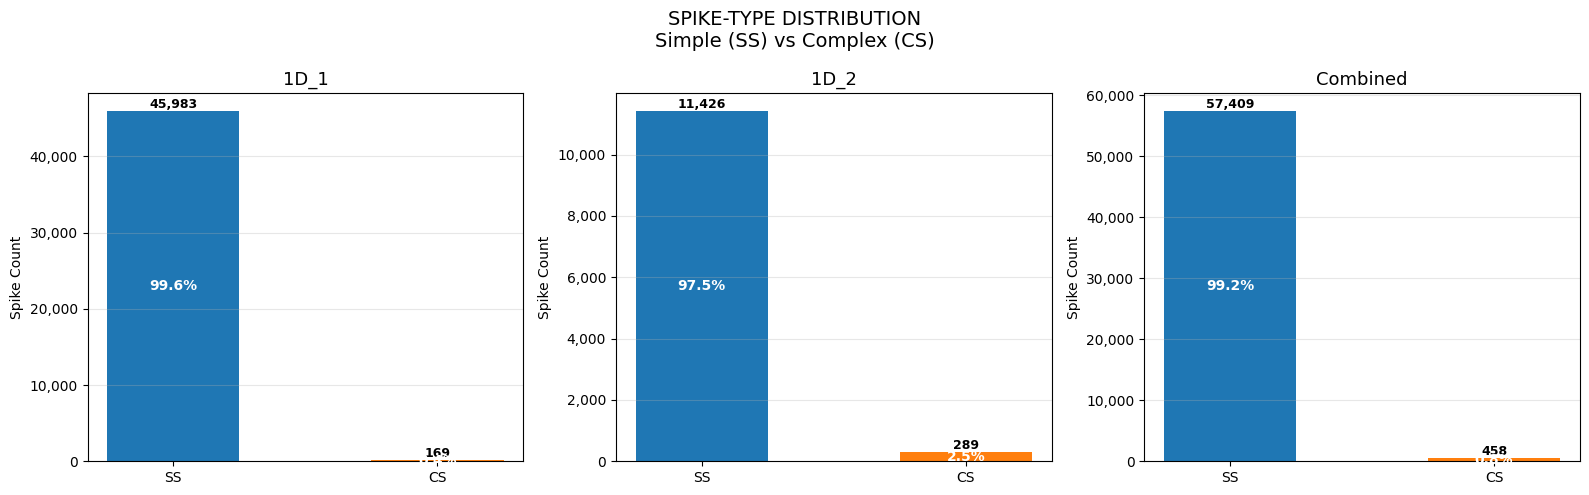

In [6]:
def plot_spike_distribution(ax, df, title):
    # Count spike types
    counts = df['spike_type'].value_counts()
    
    # Ensure consistent order
    counts = counts.reindex(['SS', 'CS'])
    
    labels = counts.index.tolist()
    values = counts.values
    total = values.sum()

    # Assign distinct colors (default palette)
    color_map = {'SS': 'tab:blue', 'CS': 'tab:orange'}
    colors = [color_map[label] for label in labels]

    # Create bar chart
    bars = ax.bar(labels, values, color=colors, width=0.5)

    # Add value labels (top)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{val:,}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    # Add percentage labels (inside)
    for bar, val in zip(bars, values):
        pct = f'{100 * val / total:.1f}%'
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            pct,
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    # Formatting
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Spike Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.grid(axis='y', alpha=0.3)


# --- Main plotting ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SPIKE-TYPE DISTRIBUTION\nSimple (SS) vs Complex (CS)', fontsize=14)

datasets = [
    ('1D_1', df1),
    ('1D_2', df2),
    ('Combined', df_all)
]

for ax, (name, df) in zip(axes, datasets):
    plot_spike_distribution(ax, df, name)

plt.tight_layout()
plt.show()

This visualization clearly shows extreme class imbalance between Simple Spikes (SS) and Complex Spikes (CS) across both recordings and in aggregate. SS dominates overwhelmingly (~99% overall), while CS - the physiologically critical but rare events—make up less than 1%. This aligns directly with the signal sparsity challenge, where meaningful events (CS) are rare but highly informative.

We must actively address imbalance during training—through class weighting, focal loss, or resampling strategies. Architecturally, this also suggests the model must be highly sensitive to rare temporal patterns, supporting the direction toward attention-based spatio-temporal models that can selectively amplify these rare but meaningful signals.

## 4 — Behavioural Label Distribution

In [7]:
def plot_label_distribution(ax, df, title, label_map=None, label_meaning=None):
    # Aggregate counts
    label_spike = df.groupby(['label', 'spike_type']).size().unstack(fill_value=0)

    # Sort labels by total count
    label_spike = label_spike.loc[label_spike.sum(axis=1).sort_values(ascending=False).index]

    # Ensure both columns exist
    for col in ['SS', 'CS']:
        if col not in label_spike.columns:
            label_spike[col] = 0

    labels = label_spike.index.tolist()

    # Build readable labels
    def format_label(l):
        name = label_map.get(l, str(l)) if label_map else str(l)
        if label_meaning and l in label_meaning:
            # Shorten meaning to avoid clutter
            meaning = label_meaning[l]
            short = meaning.split('—')[0]  # keep first part
            return f"{name}\n({short})"
        return name

    label_names = [format_label(l) for l in labels]

    x = np.arange(len(labels))
    width = 0.4

    colors = {'SS': 'tab:blue', 'CS': 'tab:orange'}

    ax.bar(x - width/2, label_spike['SS'], width, label='SS', color=colors['SS'])
    ax.bar(x + width/2, label_spike['CS'], width, label='CS', color=colors['CS'])

    ax.set_xticks(x)
    ax.set_xticklabels(label_names, fontsize=8)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Spike Count')
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

In [8]:
LABEL_MEANING = {
    1: "Task-irrelevant lick — grooming",
    2: "Inner tube success",
    3: "Inner tube fail",
    4: "Outer edge success",
    5: "Outer edge fail",
    6: "Under tube success",
    7: "Under tube fail"
}

plot_label_distribution(ax, df, name, LABEL_MAP, LABEL_MEANING)

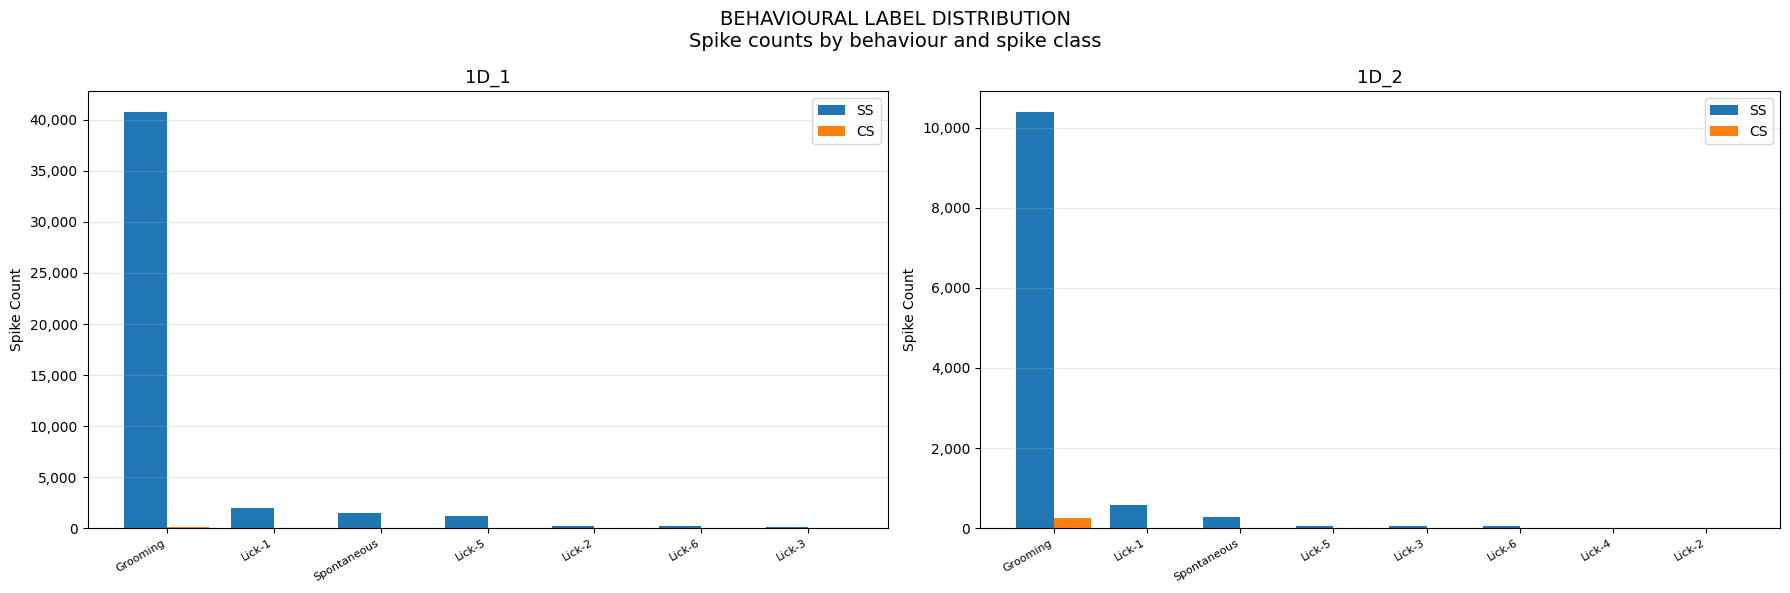

In [9]:
def plot_label_distribution(ax, df, title, label_map=None):
    # Aggregate counts
    label_spike = df.groupby(['label', 'spike_type']).size().unstack(fill_value=0)

    # Sort labels by total count
    label_spike = label_spike.loc[label_spike.sum(axis=1).sort_values(ascending=False).index]

    # Ensure both columns exist
    for col in ['SS', 'CS']:
        if col not in label_spike.columns:
            label_spike[col] = 0

    # Labels
    labels = label_spike.index.tolist()
    label_names = [label_map.get(l, str(l)) if label_map else str(l) for l in labels]

    x = np.arange(len(labels))
    width = 0.4

    # Colors (consistent with previous plot)
    colors = {'SS': 'tab:blue', 'CS': 'tab:orange'}

    # Bars
    bars_ss = ax.bar(x - width/2, label_spike['SS'], width,
                     label='SS', color=colors['SS'])
    bars_cs = ax.bar(x + width/2, label_spike['CS'], width,
                     label='CS', color=colors['CS'])

    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(label_names, rotation=30, ha='right', fontsize=8)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Spike Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.grid(axis='y', alpha=0.3)
    ax.legend()


# --- Main plotting ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(
    'BEHAVIOURAL LABEL DISTRIBUTION\nSpike counts by behaviour and spike class',
    fontsize=14
)

datasets = [
    ('1D_1', df1),
    ('1D_2', df2)
]

for ax, (name, df) in zip(axes, datasets):
    plot_label_distribution(ax, df, name, LABEL_MAP)

plt.tight_layout()
plt.show()

This plot shows a strong behavioral imbalance, with Grooming dominating the dataset by a large margin, while all licking-related classes and Spontaneous activity are comparatively sparse.

For modeling, this means the task is inherently biased toward predicting Grooming, risking poor generalization to finer motor behaviors. We’ll need behavior-aware balancing, such as stratified sampling or per-class weighting, especially if moving toward multi-class or multi-label decoding. It also suggests that decoding subtle behaviors (e.g., different lick types) will require models that can extract weak, sparse signals, further justifying attention mechanisms and careful temporal window tuning to capture nuanced distinctions.

## 5 — Velocity Distribution by Behaviour Label

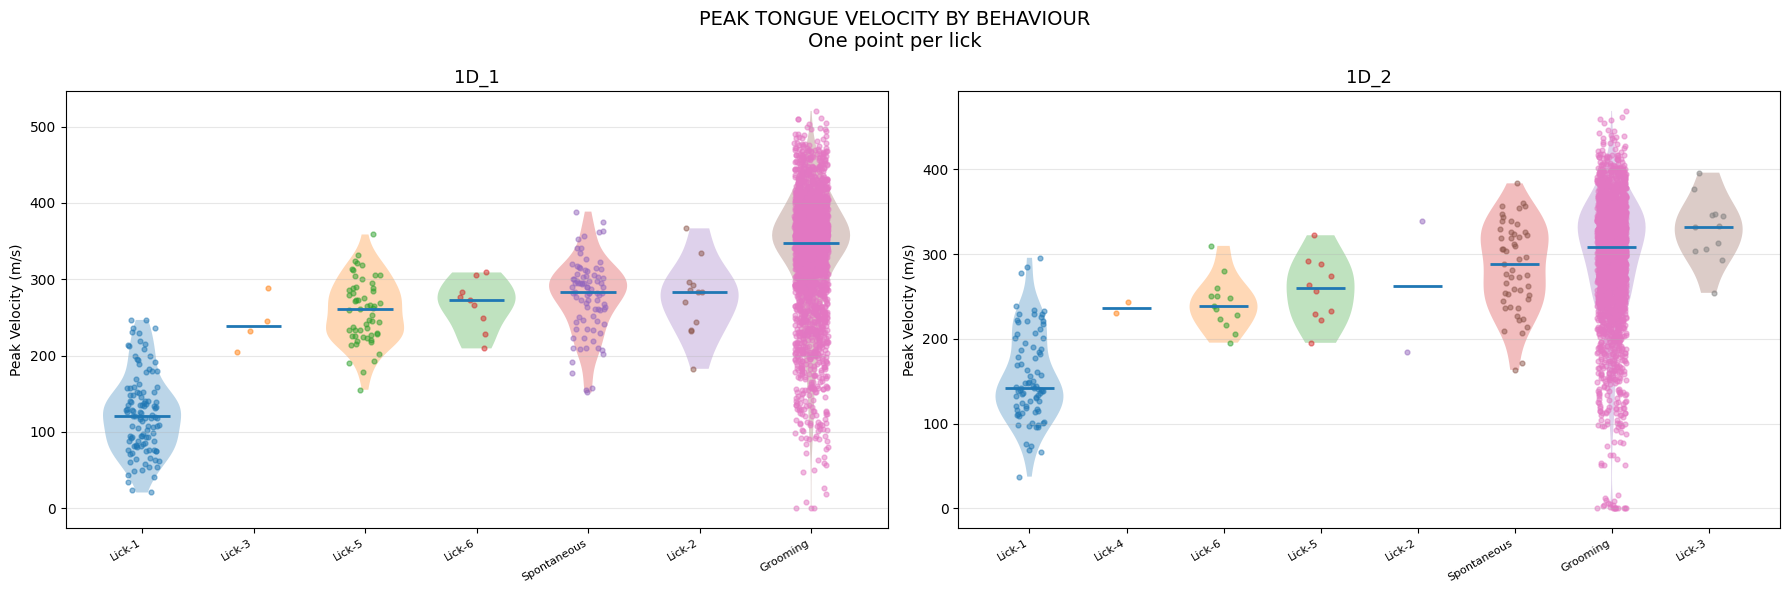

In [10]:
def plot_velocity_by_label(ax, df, title, label_map=None):
    # One row per lick
    lick_df = df.drop_duplicates('lick_id')[['label', 'velocity_max']].copy()

    # Map labels to names
    lick_df['label_name'] = lick_df['label'].map(label_map).fillna(lick_df['label'].astype(str))

    # Order by median velocity
    order = (
        lick_df.groupby('label_name')['velocity_max']
        .median()
        .sort_values()
        .index
    )

    for i, label in enumerate(order):
        vals = lick_df.loc[lick_df['label_name'] == label, 'velocity_max'].dropna()
        if len(vals) == 0:
            continue

        # Violin (only if enough data)
        if len(vals) > 5:
            vp = ax.violinplot(vals, positions=[i], widths=0.7,
                               showmedians=False, showextrema=False)
            for body in vp['bodies']:
                body.set_alpha(0.3)

        # Scatter (jittered)
        jitter = np.random.uniform(-0.15, 0.15, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   s=12, alpha=0.5)

        # Median line
        ax.hlines(np.median(vals), i - 0.25, i + 0.25,
                  linewidth=2)

    # Formatting
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Peak Velocity (m/s)')
    ax.set_title(title, fontsize=13)
    ax.grid(axis='y', alpha=0.3)


# --- Main plot ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(
    'PEAK TONGUE VELOCITY BY BEHAVIOUR\nOne point per lick',
    fontsize=14
)

datasets = [
    ('1D_1', df1),
    ('1D_2', df2)
]

for ax, (name, df) in zip(axes, datasets):
    plot_velocity_by_label(ax, df, name, LABEL_MAP)

plt.tight_layout()
plt.show()

Velocity carries meaningful signal for decoding motor output. However, the substantial overlap in distributions—especially among mid-range behaviors and within Grooming—indicates that velocity alone is not sufficient for clean class separation.

Moving forward, velocity should be treated as an informative but non-discriminative feature in isolation, meaning models must integrate it with temporal spike patterns and population activity. The high variance within behaviors (especially Grooming) also suggests the need for temporal context (windowing) and possibly attention to identify when velocity changes are behaviorally meaningful rather than noise.

## 6 — Deceleration Strength vs Peak Velocity

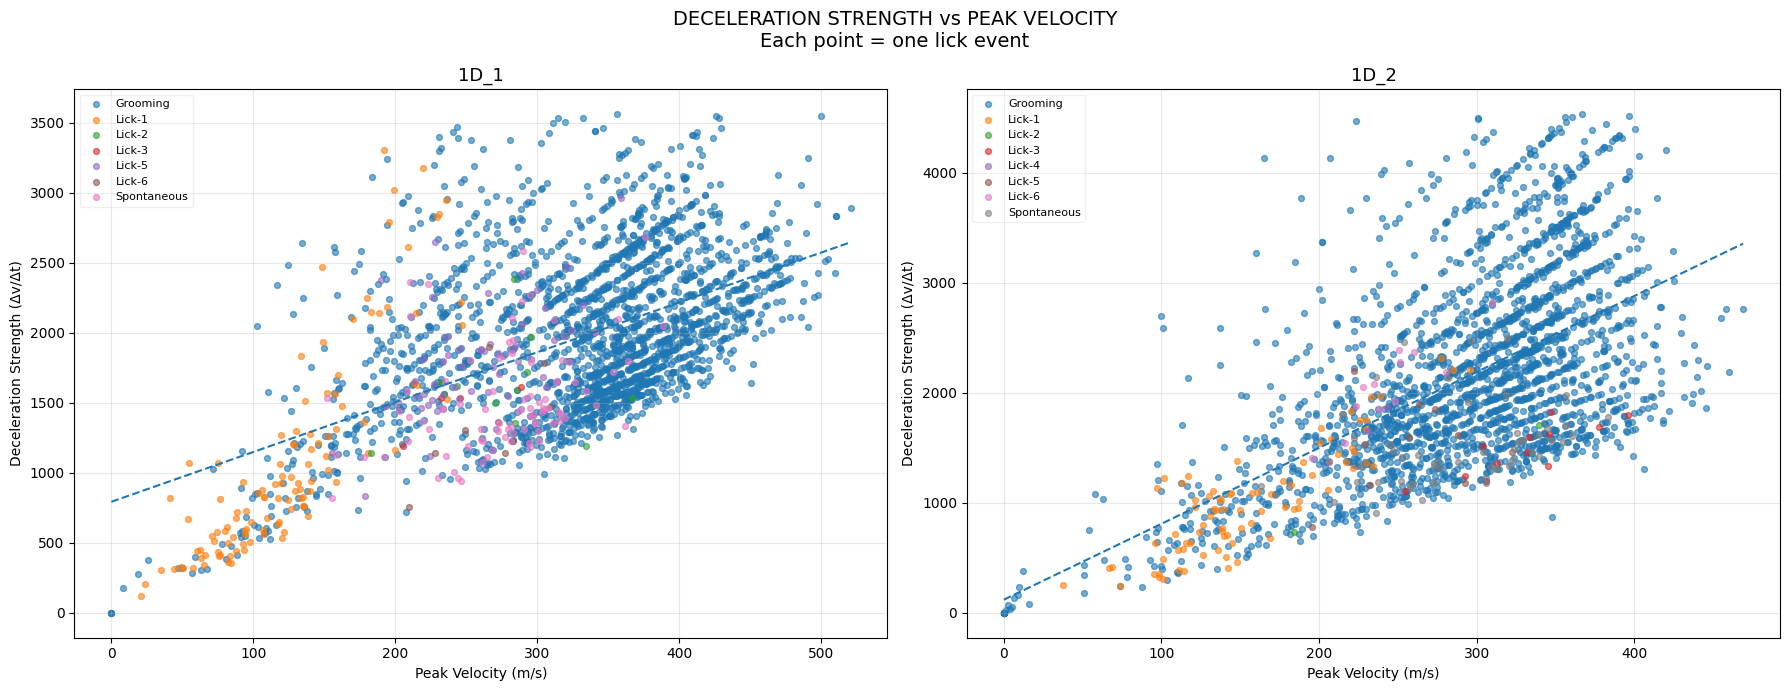

In [11]:
def plot_decel_vs_velocity(ax, df, title, label_map=None):
    # One row per lick
    lick_df = (
        df.drop_duplicates('lick_id')[['label', 'velocity_max', 'decel_strength']]
        .dropna()
        .copy()
    )

    # Map labels
    lick_df['label_name'] = lick_df['label'].map(label_map).fillna(lick_df['label'].astype(str))

    # Remove extreme outliers (top 2%)
    q_hi = lick_df['decel_strength'].quantile(0.98)
    lick_df = lick_df[lick_df['decel_strength'] < q_hi]

    # Plot each label group
    for label, group in lick_df.groupby('label_name'):
        ax.scatter(
            group['velocity_max'],
            group['decel_strength'],
            s=18,
            alpha=0.6,
            label=label
        )

    # Trend line (global)
    if len(lick_df) > 10:
        m, b = np.polyfit(lick_df['velocity_max'], lick_df['decel_strength'], 1)
        xs = np.linspace(lick_df['velocity_max'].min(),
                         lick_df['velocity_max'].max(), 100)
        ax.plot(xs, m * xs + b, linestyle='--', linewidth=1.5)

    # Formatting
    ax.set_xlabel('Peak Velocity (m/s)')
    ax.set_ylabel('Deceleration Strength (Δv/Δt)')
    ax.set_title(title, fontsize=13)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, framealpha=0.3)


# --- Main plot ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'DECELERATION STRENGTH vs PEAK VELOCITY\nEach point = one lick event',
    fontsize=14
)

datasets = [
    ('1D_1', df1),
    ('1D_2', df2)
]

for ax, (name, df) in zip(axes, datasets):
    plot_decel_vs_velocity(ax, df, name, LABEL_MAP)

plt.tight_layout()
plt.show()

This plot reveals a clear positive relationship between peak velocity and deceleration strength, indicating that deceleration is not independent but tightly coupled to movement dynamics. This is important because it aligns with physiological findings that Purkinje cells encode movement deceleration as part of motor control.

For modeling, this suggests that deceleration is a highly informative target signal but not sufficient in isolation for classification. Instead, it strengthens your direction toward decoding continuous motor variables (like deceleration) rather than only discrete labels.

## 7 — Spike Timing Density Heatmap (SS vs CS)

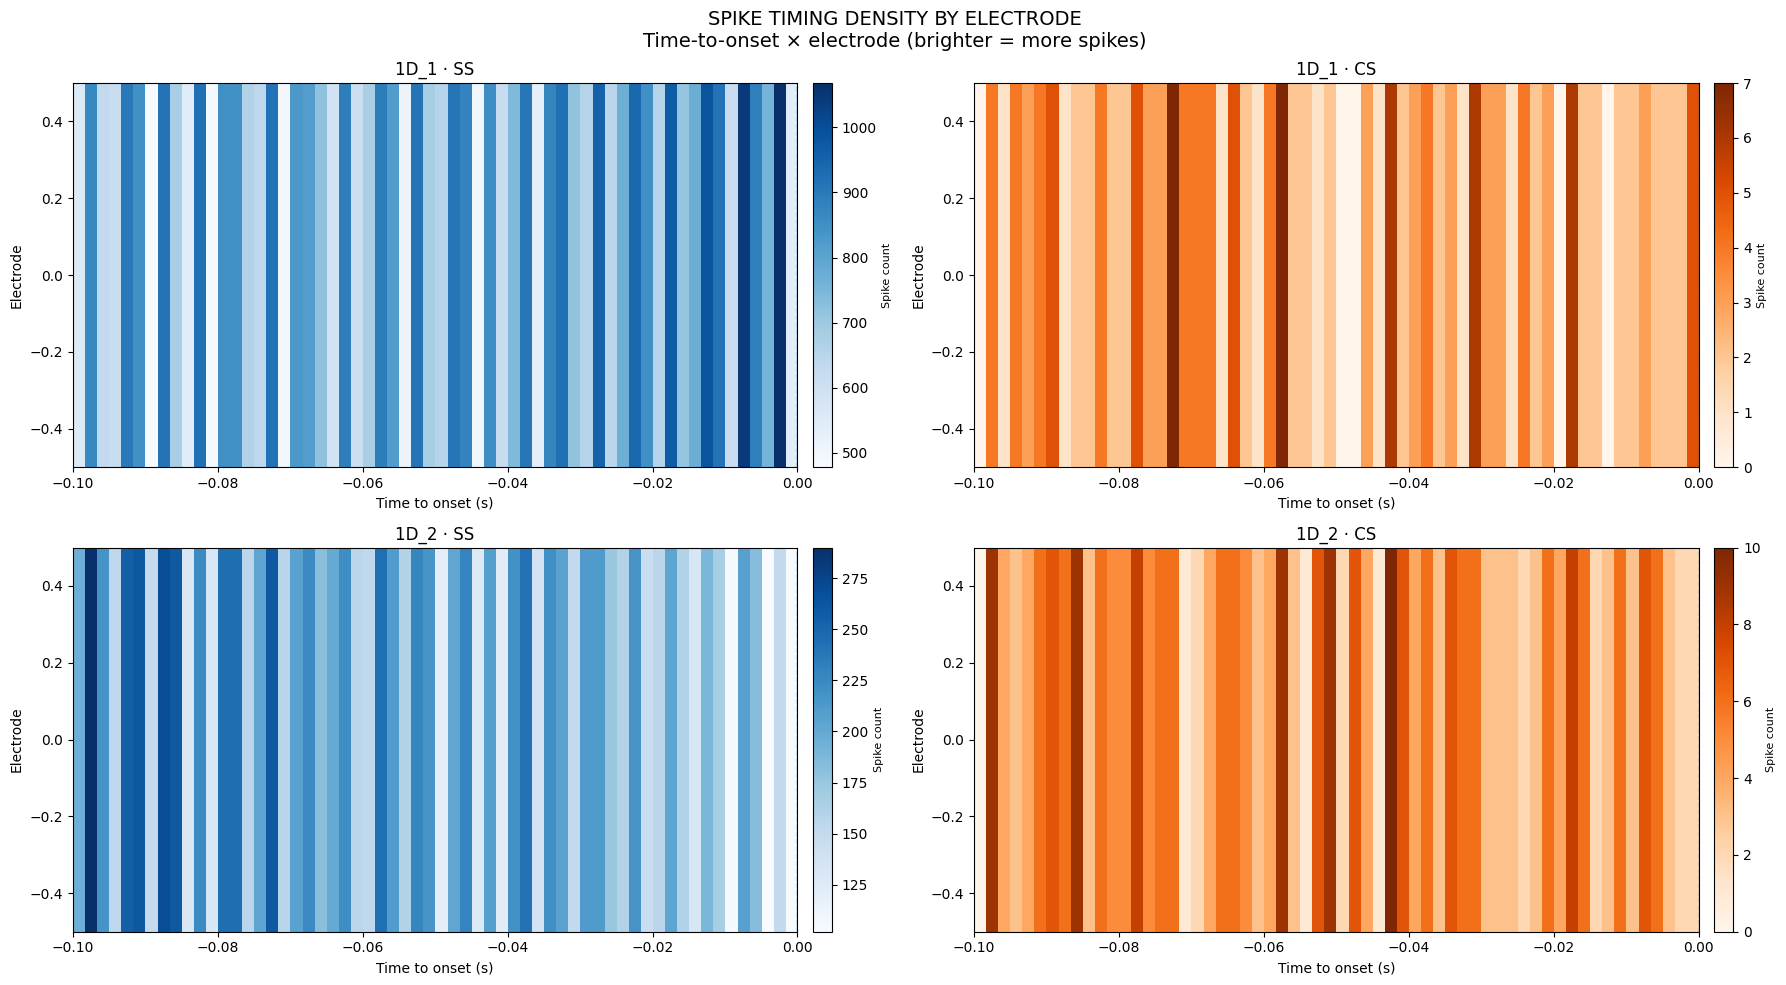

In [ ]:
def plot_spike_timing_heatmap(ax, df, spike_type, title):
    # Filter data
    sub = df[df['spike_type'] == spike_type]

    # Number of electrodes
    n_elec = df['electrode'].nunique()

    # 2D histogram
    h, xedges, yedges = np.histogram2d(
        sub['spike_time'],
        sub['electrode'],
        bins=[60, n_elec],
        range=[[-0.1, 0.0], [-0.5, n_elec - 0.5]]
    )

    # Use simple default colormaps
    cmap = 'Blues' if spike_type == 'SS' else 'Oranges'

    im = ax.imshow(
        h.T,
        origin='lower',
        aspect='auto',
        cmap=cmap,
        extent=[-0.1, 0.0, -0.5, n_elec - 0.5]
    )

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_label('Spike count', fontsize=8)

    # Formatting
    ax.axvline(0, linestyle='--', linewidth=1)  
    ax.set_title(f'{title} · {spike_type}', fontsize=12)
    ax.set_xlabel('Time to onset (s)')
    ax.set_ylabel('Electrode')


# --- Main plot ---
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle(
    'SPIKE TIMING DENSITY BY ELECTRODE\nTime-to-onset × electrode (brighter = more spikes)',
    fontsize=14
)

datasets = [
    ('1D_1', df1),
    ('1D_2', df2)
]

for row, (name, df) in enumerate(datasets):
    for col, stype in enumerate(['SS', 'CS']):
        plot_spike_timing_heatmap(axes[row, col], df, stype, name)

plt.tight_layout()
plt.show()

This visualization shows that spike activity is temporally structured relative to behavior onset, rather than random. SS activity is dense and smoothly distributed across time, suggesting it provides a continuous background signal, while CS activity is sparse but shows localized bursts at specific pre-onset times. This reinforces the idea that CS events are rare but temporally precise and potentially more informative.

For modeling, this strongly supports using time-aligned windows centered on behavioral onset and architectures that capture temporal precision (e.g., attention over time).

## 8 — Lick-Level Feature Correlation Matrix

In [13]:
def add_title_bar(fig, title, subtitle=None):
    """
    Adds a clean title + subtitle at the top of a figure.
    """

    # Main title
    fig.text(
        0.5, 0.96,
        title,
        ha='center',
        va='top',
        fontsize=16,
        fontweight='bold'
    )

    # Subtitle (optional)
    if subtitle:
        fig.text(
            0.5, 0.92,
            subtitle,
            ha='center',
            va='top',
            fontsize=11,
            color='gray'
        )

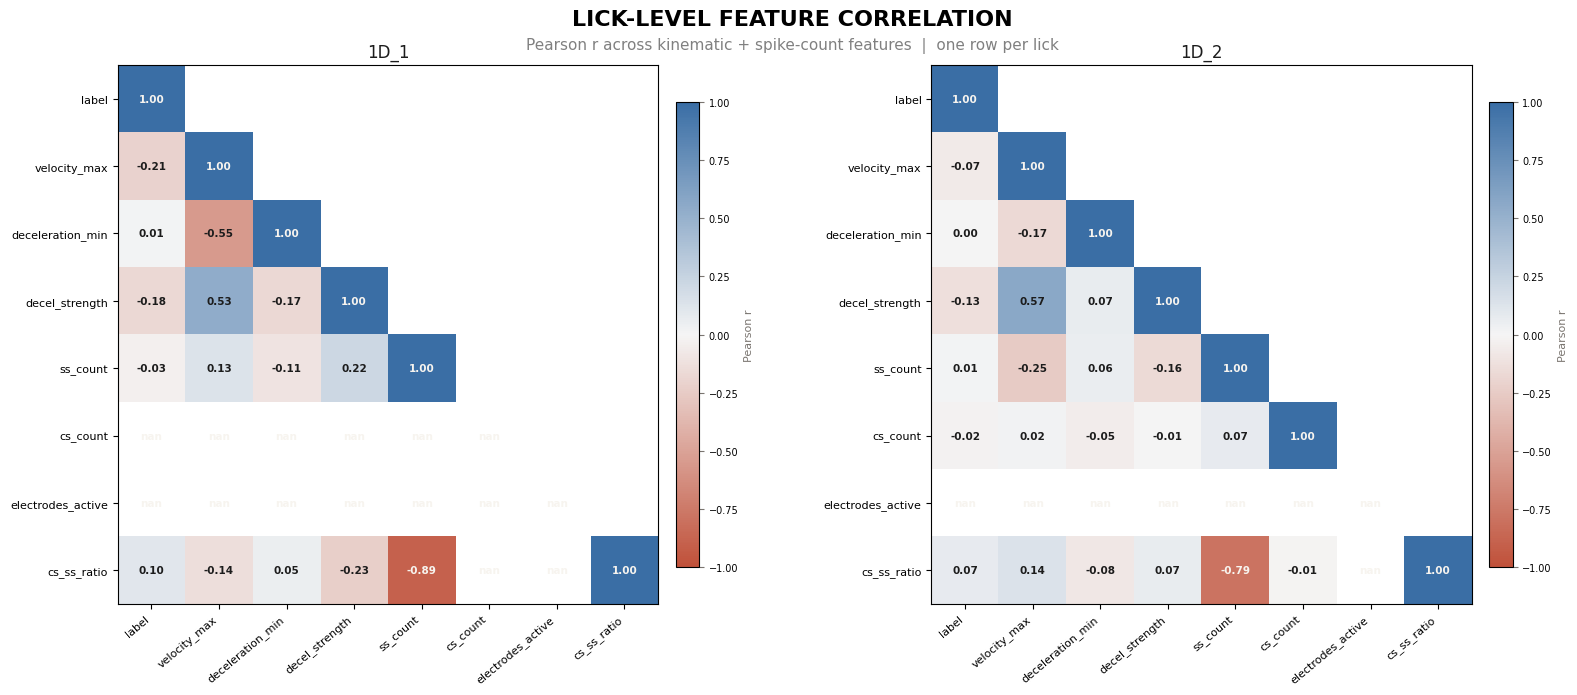

In [14]:
# --- Helper: build feature table ---
def build_feature_table(df):
    lick_base = (
        df.drop_duplicates('lick_id')
        .set_index('lick_id')[['label', 'velocity_max', 'deceleration_min', 'decel_strength']]
    )

    ss = df[df['spike_type'] == 'SS'].groupby('lick_id').size().rename('ss_count')
    cs = df[df['spike_type'] == 'CS'].groupby('lick_id').size().rename('cs_count')
    elec = df.groupby('lick_id')['electrode'].nunique().rename('electrodes_active')

    feat = lick_base.join([ss, cs, elec]).dropna()
    feat['cs_ss_ratio'] = feat['cs_count'] / feat['ss_count'].replace(0, np.nan)

    return feat


# --- Helper: plot correlation matrix ---
def plot_corr(ax, feat, title):
    corr = feat.corr(numeric_only=True)

    # Mask upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    corr_masked = corr.mask(mask)

    # Heatmap
    im = ax.imshow(corr_masked, cmap=CMAP_DUAL, vmin=-1, vmax=1, aspect='auto')

    # Annotate values
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            if not mask[i, j]:
                val = corr.iloc[i, j]
                color = TEXT if abs(val) < 0.6 else BG
                ax.text(j, i, f'{val:.2f}',
                        ha='center', va='center',
                        fontsize=7.5, color=color, fontweight='bold')

    # Axis labels
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=40, ha='right', fontsize=8)
    ax.set_yticklabels(corr.columns, fontsize=8)

    ax.set_title(title, color=TEXT)

    return im


# --- Main plot ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.subplots_adjust(top=0.88, wspace=0.4)

add_title_bar(
    fig,
    'LICK-LEVEL FEATURE CORRELATION',
    'Pearson r across kinematic + spike-count features  |  one row per lick'
)

datasets = [
    ('1D_1', df1),
    ('1D_2', df2)
]

for ax, (name, df) in zip(axes, datasets):
    feat = build_feature_table(df)
    im = plot_corr(ax, feat, name)

    # Colorbar per subplot
    cb = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
    cb.set_label('Pearson r', color=MUTED, fontsize=8)
    cb.ax.yaxis.set_tick_params(color=MUTED, labelsize=7)

plt.show()

This correlation matrix shows that no single feature strongly explains behavior labels, reinforcing the complexity of the decoding task. Correlations between kinematic features and labels are weak (mostly |r| < 0.2), meaning behavior cannot be linearly separated using simple features.

However, there is structure: velocity and deceleration strength are moderately correlated (~0.5), confirming earlier plots, and SS count shows weak relationships, while CS-related features are nearly uncorrelated due to sparsity. The strong negative correlation between SS count and CS/SS ratio (~-0.8) is expected but not directly behavior-informativ

## 9 — Cumulative Spike Count Over Lick Sequence

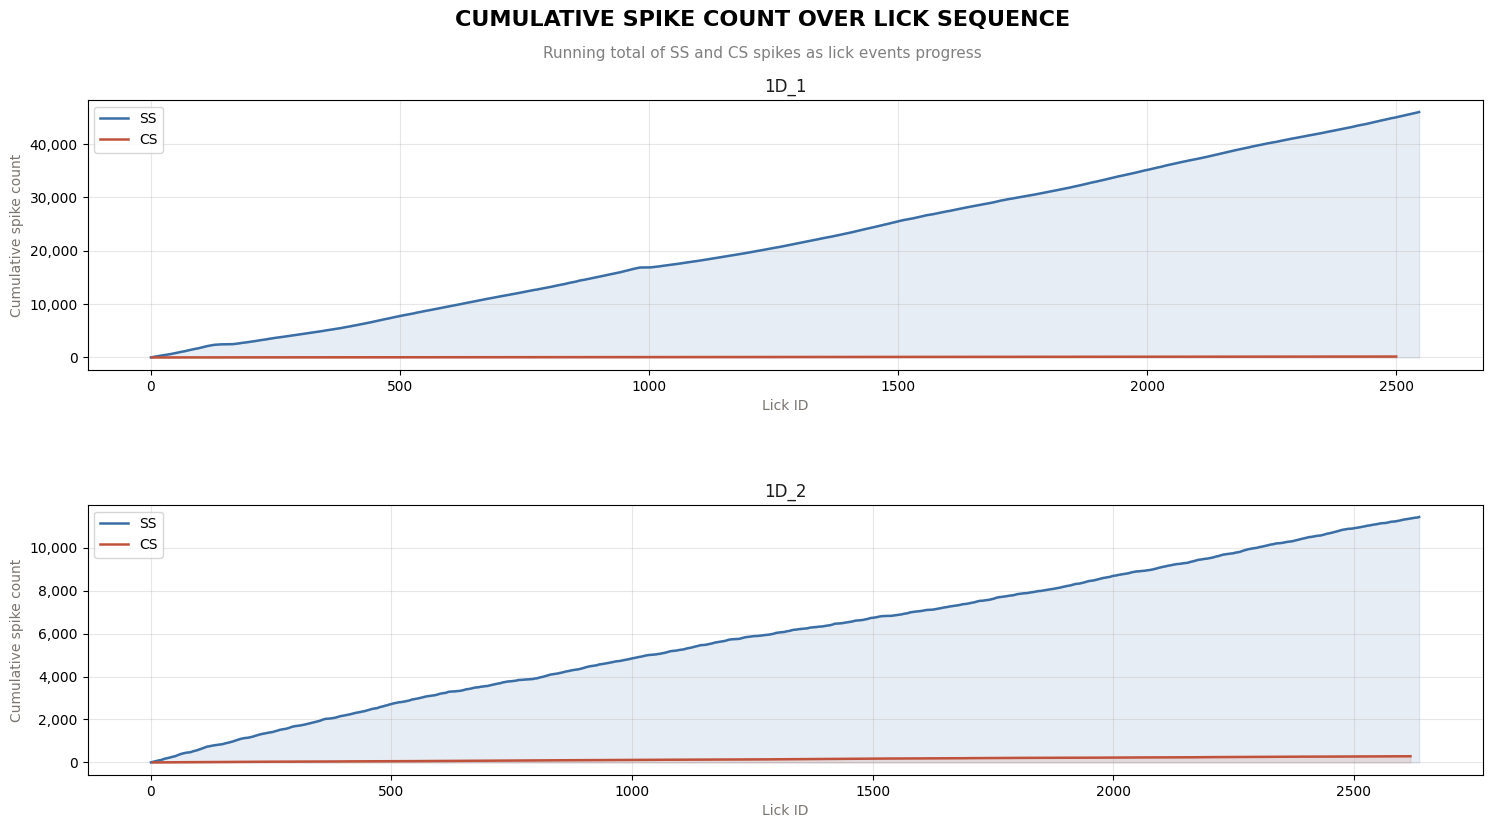

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=False)
fig.subplots_adjust(top=0.86, hspace=0.5)
add_title_bar(fig, 'CUMULATIVE SPIKE COUNT OVER LICK SEQUENCE',
              'Running total of SS and CS spikes as lick events progress')

for ax, (name, df) in zip(axes, [('1D_1', df1), ('1D_2', df2)]):
    for stype, color in [('SS', ACCENT1), ('CS', ACCENT2)]:
        sub = df[df['spike_type'] == stype]
        cum = sub.groupby('lick_id').size().sort_index().cumsum()
        ax.plot(cum.index, cum.values, color=color, linewidth=1.8, label=stype)
        ax.fill_between(cum.index, cum.values, alpha=0.12, color=color)

    ax.set_title(name, color=TEXT)
    ax.set_xlabel('Lick ID', color=MUTED)
    ax.set_ylabel('Cumulative spike count', color=MUTED)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend()
    ax.grid(alpha=0.3)

plt.show()

There are no obvious abrupt changes or phases in cumulative curves, suggesting that behavioral information is not encoded in global spike counts over long sequences, but likely in local temporal patterns around each lick. This aligns with your task framing that meaningful signals are temporally precise rather than globally aggregated.

For modeling, this implies cumulative or aggregated features are not useful; instead, we should focus on short, aligned temporal windows per event.

## 10 — Cross-Dataset Comparison Summary

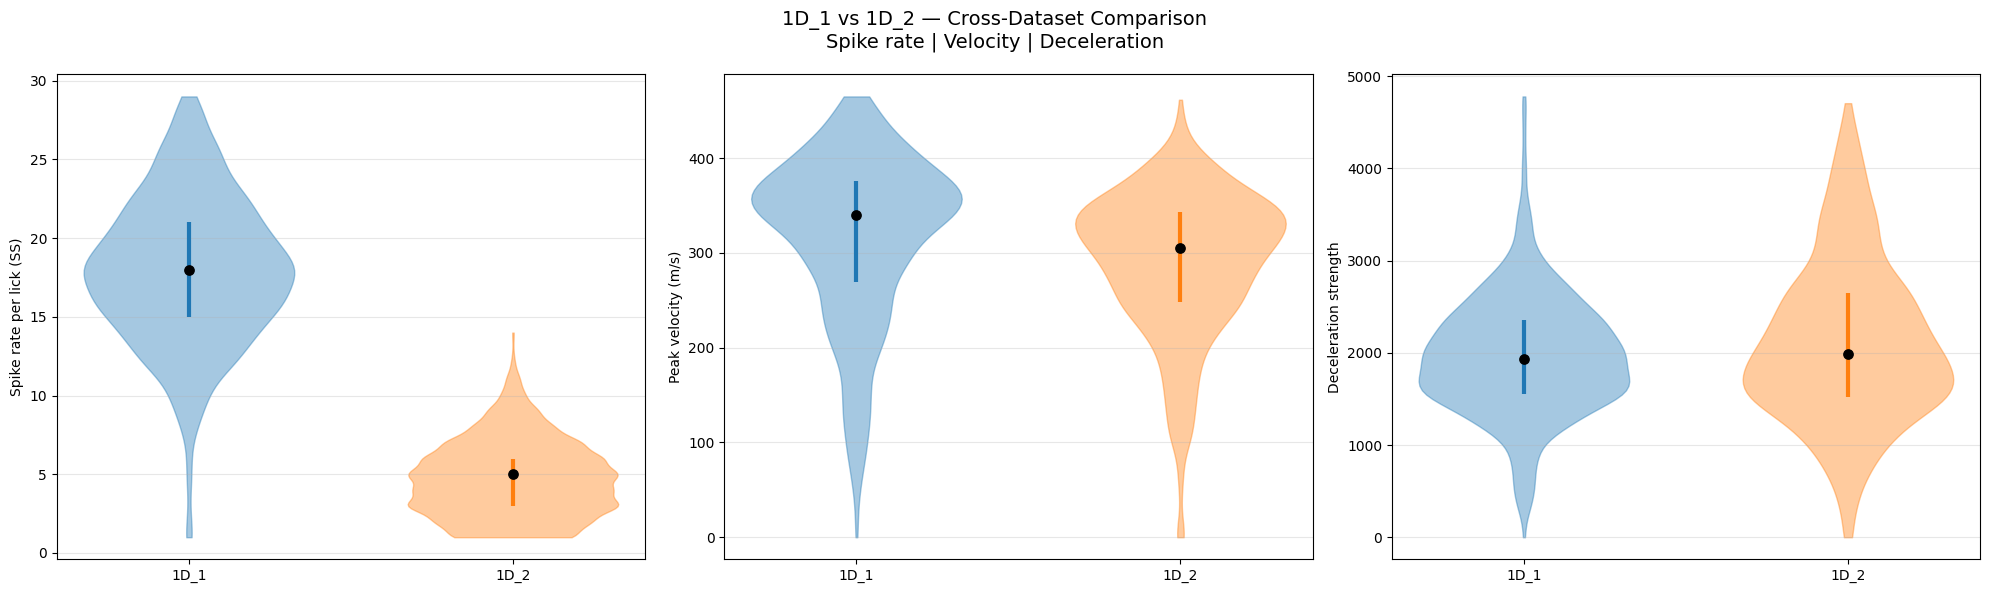

In [17]:
# --- Helper: build per-lick summary ---
def build_lick_summary(df, source):
    base = df.drop_duplicates('lick_id').set_index('lick_id')

    ss_rate = (
        df[df['spike_type'] == 'SS']
        .groupby('lick_id')
        .size()
        .rename('ss_rate')
    )

    out = base[['velocity_max', 'decel_strength']].join(ss_rate)
    out['source'] = source
    return out


# --- Helper: plot one feature ---
def plot_feature(ax, data, feature, ylabel):
    d1 = data[data['source'] == '1D_1'][feature].dropna()
    d2 = data[data['source'] == '1D_2'][feature].dropna()

    # Clip extreme outliers (top 1%)
    combined = pd.concat([d1, d2])
    p99 = np.percentile(combined, 99)
    d1 = d1[d1 < p99]
    d2 = d2[d2 < p99]

    # Colors
    colors = ['tab:blue', 'tab:orange']

    # Violin plot
    vp = ax.violinplot([d1, d2], positions=[0, 1],
                       widths=0.65, showmedians=False, showextrema=False)

    for body, c in zip(vp['bodies'], colors):
        body.set_facecolor(c)
        body.set_edgecolor(c)
        body.set_alpha(0.4)

    # Median + IQR
    for i, (vals, c) in enumerate([(d1, colors[0]), (d2, colors[1])]):
        if len(vals) == 0:
            continue
        q25, med, q75 = np.percentile(vals, [25, 50, 75])
        ax.vlines(i, q25, q75, color=c, linewidth=3)
        ax.scatter(i, med, color='black', s=45, zorder=3)

    # Formatting
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['1D_1', '1D_2'])
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)


# --- Build combined dataset ---
cmp = pd.concat([
    build_lick_summary(df1, '1D_1'),
    build_lick_summary(df2, '1D_2')
])


# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    '1D_1 vs 1D_2 — Cross-Dataset Comparison\nSpike rate | Velocity | Deceleration',
    fontsize=14
)

features = [
    ('ss_rate', 'Spike rate per lick (SS)'),
    ('velocity_max', 'Peak velocity (m/s)'),
    ('decel_strength', 'Deceleration strength')
]

for ax, (feat, label) in zip(axes, features):
    plot_feature(ax, cmp, feat, label)

plt.tight_layout()
plt.show()

1D_1 has significantly higher SS spike rates per lick (~18 vs ~5), indicating different recording conditions or neural activity regimes. In contrast, velocity and deceleration distributions are relatively aligned across datasets, suggesting behavioral outputs are consistent while neural representations vary.

Moving forward, this implies the need for normalization or domain-invariant representations, and potentially training strategies like cross-validation across sessions or domain adaptation.

## 11 — EDA Summary

In [18]:
print('═' * 60)
print('  EDA COMPLETE — KEY FINDINGS')
print('═' * 60)

for name, df in [('1D_1', df1), ('1D_2', df2)]:
    lick_df = df.drop_duplicates('lick_id')
    ss = df[df['spike_type']=='SS']
    cs = df[df['spike_type']=='CS']

    print(f'\n  {name}')
    print(f'    Licks             : {df["lick_id"].nunique():>6,}')
    print(f'    SS spikes         : {len(ss):>6,}  ({100*len(ss)/len(df):.1f}%)')
    print(f'    CS spikes         : {len(cs):>6,}  ({100*len(cs)/len(df):.1f}%)')
    print(f'    Velocity median   : {lick_df["velocity_max"].median():>6.3f} m/s')
    print(f'    Decel str median  : {lick_df["decel_strength"].median():>6.2f}')
    print(f'    Active electrodes : {df["electrode"].nunique():>6}')
    print(f'    Behaviour labels  : {sorted(df["label"].unique())}')

print()
print('  Saved plots:')
for fname in [
    'eda_spike_type_dist.png', 'eda_label_dist.png',
    'eda_raster_1D_1_SS.png', 'eda_raster_1D_1_CS.png',
    'eda_raster_1D_2_SS.png', 'eda_raster_1D_2_CS.png',
    'eda_electrode_rate.png', 'eda_velocity_by_label.png',
    'eda_decel_vs_velocity.png', 'eda_timing_heatmap.png',
    'eda_cs_ss_ratio.png', 'eda_correlation_matrix.png',
    'eda_cumulative_spikes.png', 'eda_isi.png', 'eda_cross_dataset.png'
]:
    print(f'    {fname}')
print('═' * 60)

════════════════════════════════════════════════════════════
  EDA COMPLETE — KEY FINDINGS
════════════════════════════════════════════════════════════

  1D_1
    Licks             :  2,521
    SS spikes         : 45,983  (99.6%)
    CS spikes         :    169  (0.4%)
    Velocity median   : 340.826 m/s
    Decel str median  : 1934.74
    Active electrodes :      1
    Behaviour labels  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7)]

  1D_2
    Licks             :  2,461
    SS spikes         : 11,426  (97.5%)
    CS spikes         :    289  (2.5%)
    Velocity median   : 304.980 m/s
    Decel str median  : 1996.06
    Active electrodes :      1
    Behaviour labels  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

  Saved plots:
    eda_spike_type_dist.png
    eda_label_dist.png
    eda_raster_1D_1_SS.png
    eda_raster_1D_1_CS.png
    eda_raster_1D_2_SS.png
    eda_raster_1D_2_C